# Correlation functions of code length

The code length $\ell_n = -\log_2 P(t_{n+1} \mid t_{1\cdots n})$ is a local "energy density" assigned by the LLM at each token position. Here we compute its two-point (auto)correlation function

$$C(d) = \langle \delta\ell_n \, \delta\ell_{n+d} \rangle, \qquad \delta\ell_n = \ell_n - \bar\ell_n$$

where the average is over sequences and token positions, and look at characteristic time scales.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import os

## 1. Load precomputed code lengths

The Colin pipeline already saved per-token code lengths as `.npy` arrays of shape `(batch, seq_len)`.  We load them and concatenate into a large `(N_seqs, T)` matrix.

In [6]:
data_root = Path('/scratch/gpfs/WBIALEK/ls1546/llms-entropy/colin_files_dclm/data')

# Available corpora
print('Available corpora:', sorted(os.listdir(data_root)))

Available corpora: ['BBC', 'BookChapter', 'BooksumAnalysis', 'BooksumText', 'c4', 'gpc', 'newc4', 'newc4_18000', 'newc4_27000', 'newc4_36000', 'newc4_9000', 'poetry', 'simple', 'wiki']


In [ ]:
def load_codelengths(corpus_dir, max_files=None):
    """Load per-token code lengths and attention masks from a corpus directory.
    
    Handles two layouts:
      - Flat: corpus_dir/codelength_t/*.npy  (e.g. c4)
      - Grouped: corpus_dir/group_XXXXX/codelength_t/*.npy  (e.g. newc4)
    
    Parameters
    ----------
    corpus_dir : Path
    max_files : int or None
        Cap on total number of .npy files loaded (across all groups).
    
    Returns
    -------
    cl : ndarray, shape (N_seqs, T)
        Code lengths in bits at each token position.
    attn : ndarray, shape (N_seqs, T+1)
        Attention mask (1 = real token, 0 = padding).
    """
    if (corpus_dir / 'codelength_t').is_dir():
        group_dirs = [corpus_dir]
    else:
        group_dirs = sorted(
            p for p in corpus_dir.iterdir()
            if p.is_dir() and p.name.startswith('group_')
        )
    
    cl_list, attn_list = [], []
    n_loaded = 0
    for gdir in group_dirs:
        cl_dir = gdir / 'codelength_t'
        attn_dir = gdir / 'attn'
        files = sorted(f for f in os.listdir(cl_dir) if f.endswith('.npy'))
        for f in tqdm(files, desc=f'Loading {gdir.name}', leave=False):
            cl_list.append(np.load(cl_dir / f))
            attn_list.append(np.load(attn_dir / f))
            n_loaded += 1
            if max_files is not None and n_loaded >= max_files:
                break
        if max_files is not None and n_loaded >= max_files:
            break
    
    cl = np.concatenate(cl_list, axis=0)
    attn = np.concatenate(attn_list, axis=0)
    print(f'Loaded {cl.shape[0]} sequnces ({n_loaded} files) from {corpus_dir.name}, '
          f'{cl.shape[1]} positions each')
    return cl, attn


In [ ]:
# newc4: grouped structure (group_00000 … group_00004), 5 seqs per file, ~2046 positions
corpus = 'newc4'
cl, attn = load_codelengths(data_root / corpus, max_files=2000)

Loaded 10000 documents (2000 files) from newc4, 2046 positions each


In [9]:
print(f'Code lengths: shape={cl.shape}, dtype={cl.dtype}')
print(f'Attention:    shape={attn.shape}, dtype={attn.dtype}')
print(f'Global mean code length: {cl.mean():.3f} bits')
print(f'Global std:  {cl.std():.3f} bits')

Code lengths: shape=(10000, 2046), dtype=float32
Attention:    shape=(10000, 2047), dtype=int64
Global mean code length: 3.938 bits
Global std:  3.932 bits


## 2. Position-dependent mean and variance

The mean code length $\bar\ell(n)$ decreases with position $n$ (more context → better predictions). Before computing correlations, let's see this structure and decide how to handle it.

In [10]:
# Mask for valid tokens: attention mask shifted to match codelength indexing
# attn has shape (N, T+1), codelength has shape (N, T)
# codelength at position t corresponds to predicting token t+1 given tokens 0..t
mask = attn[:, 1:cl.shape[1]+1].astype(bool)

# Position-dependent mean and variance
count_per_pos = mask.sum(axis=0)
mean_per_pos = np.where(count_per_pos > 0, (cl * mask).sum(axis=0) / count_per_pos, 0)
var_per_pos = np.where(count_per_pos > 0,
                       ((cl - mean_per_pos)**2 * mask).sum(axis=0) / count_per_pos, 0)

positions = np.arange(1, cl.shape[1] + 1)  # 1-indexed context length

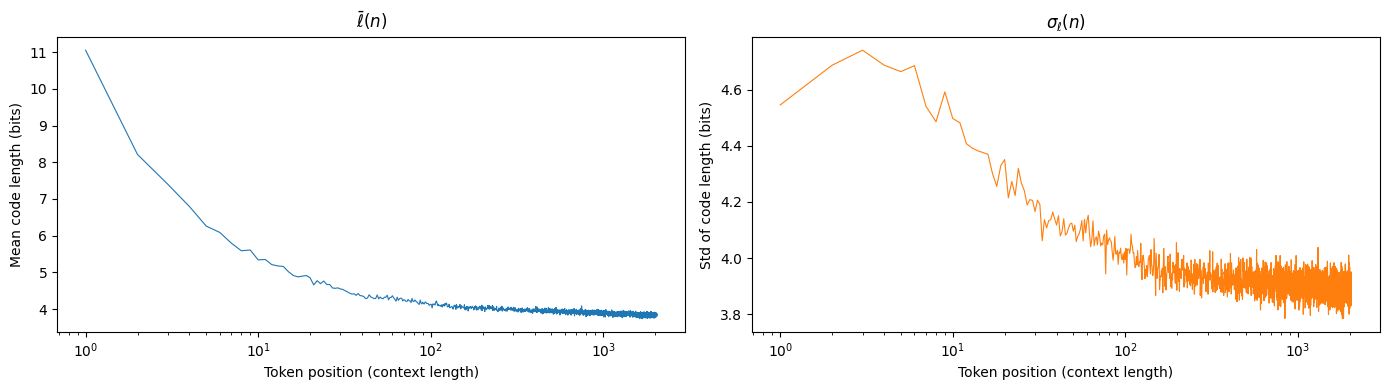

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(positions, mean_per_pos, lw=0.8)
axes[0].set_xlabel('Token position (context length)')
axes[0].set_ylabel('Mean code length (bits)')
axes[0].set_title('$\\bar{\\ell}(n)$')

axes[1].plot(positions, np.sqrt(var_per_pos), lw=0.8, color='C1')
axes[1].set_xlabel('Token position (context length)')
axes[1].set_ylabel('Std of code length (bits)')
axes[1].set_title('$\\sigma_\\ell(n)$')

for ax in axes:
    ax.set_xscale('log')
plt.tight_layout()
plt.show()

## 3. Two-point correlation function

We compute the connected correlator
$$C(d) = \frac{1}{N_{\rm pairs}(d)} \sum_{\text{seqs}} \sum_n \delta\ell_n \, \delta\ell_{n+d}$$

where $\delta\ell_n = \ell_n - \bar\ell(n)$ subtracts the position-dependent mean.

We can also normalize to get the autocorrelation coefficient $\rho(d) = C(d) / C(0)$.

We use direct summation: for each lag $d$, compute the product $\delta\ell_n\,\delta\ell_{n+d}$ across all valid pairs and average.  This is transparent and easy to check.

In [19]:
# Subtract position-dependent mean to get fluctuations
delta_cl = (cl - mean_per_pos) * mask  # zero out padding positions

In [ ]:
def corr_direct(delta, mask, max_lag=None):
    """Direct computation of the two-point correlation function.
    
    For each lag d, computes
        C(d) = <delta[n] * delta[n+d]>  over valid pairs.
    
    Parameters
    ----------
    delta : ndarray (N_seqs, T) — fluctuations (mean-subtracted, zeros in padding)
    mask  : ndarray (N_seqs, T) — boolean mask (True = valid)
    max_lag : int or None
        Maximum lag to compute.  Defaults to T-1.
    
    Returns
    -------
    C : ndarray (max_lag+1,) — C(d) for d = 0, 1, ..., max_lag
    npairs : ndarray (max_lag+1,) — number of valid pairs at each lag
    """
    N, T = delta.shape
    if max_lag is None:
        max_lag = T - 1
    max_lag = min(max_lag, T - 1)
    
    C = np.zeros(max_lag + 1)
    npairs = np.zeros(max_lag + 1)
    
    for d in tqdm(range(max_lag + 1), desc='Direct correlations', leave=False):
        prod = delta[:, :T-d] * delta[:, d:T]
        valid = mask[:, :T-d] & mask[:, d:T]
        npairs[d] = valid.sum()
        C[d] = prod[valid].sum() / npairs[d] if npairs[d] > 0 else 0
    
    return C, npairs


In [21]:
C_all, npairs_all = corr_direct(delta_cl.astype(np.float64), mask)


In [22]:
print(f'C(0) = {C_all[0]:.4f} bits^2  (should be close to global variance {(delta_cl**2 * mask).sum() / mask.sum():.4f})')
print(f'C(1) = {C_all[1]:.4f}')
print(f'C(10) = {C_all[10]:.4f}')
print(f'C(100) = {C_all[100]:.4f}')


C(0) = 15.3887 bits^2  (should be close to global variance 15.3887)
C(1) = 0.7713
C(10) = 0.8075
C(100) = 0.6272


In [23]:
# Pairs count at a few lags — useful diagnostic
for d in [0, 1, 10, 100, 500, 1000]:
    if d < len(npairs_all):
        print(f'lag {d:5d}: {int(npairs_all[d]):>12,} pairs')


lag     0:   20,460,000 pairs
lag     1:   20,450,000 pairs
lag    10:   20,360,000 pairs
lag   100:   19,460,000 pairs
lag   500:   15,460,000 pairs
lag  1000:   10,460,000 pairs


In [24]:
# Spot-check: C(0) should equal the masked variance
var_check = (delta_cl.astype(np.float64)**2 * mask).sum() / mask.sum()
print(f'C(0) = {C_all[0]:.6f},  masked variance = {var_check:.6f},  ratio = {C_all[0]/var_check:.6f}')


C(0) = 15.388738,  masked variance = 15.388738,  ratio = 1.000000


In [35]:
# save the correlation function
np.save('/scratch/gpfs/WBIALEK/ls1546/llms-entropy/C_all.npy', C_all)
np.save('/scratch/gpfs/WBIALEK/ls1546/llms-entropy/npairs_all.npy', npairs_all)

## 4. Visualize the correlation function

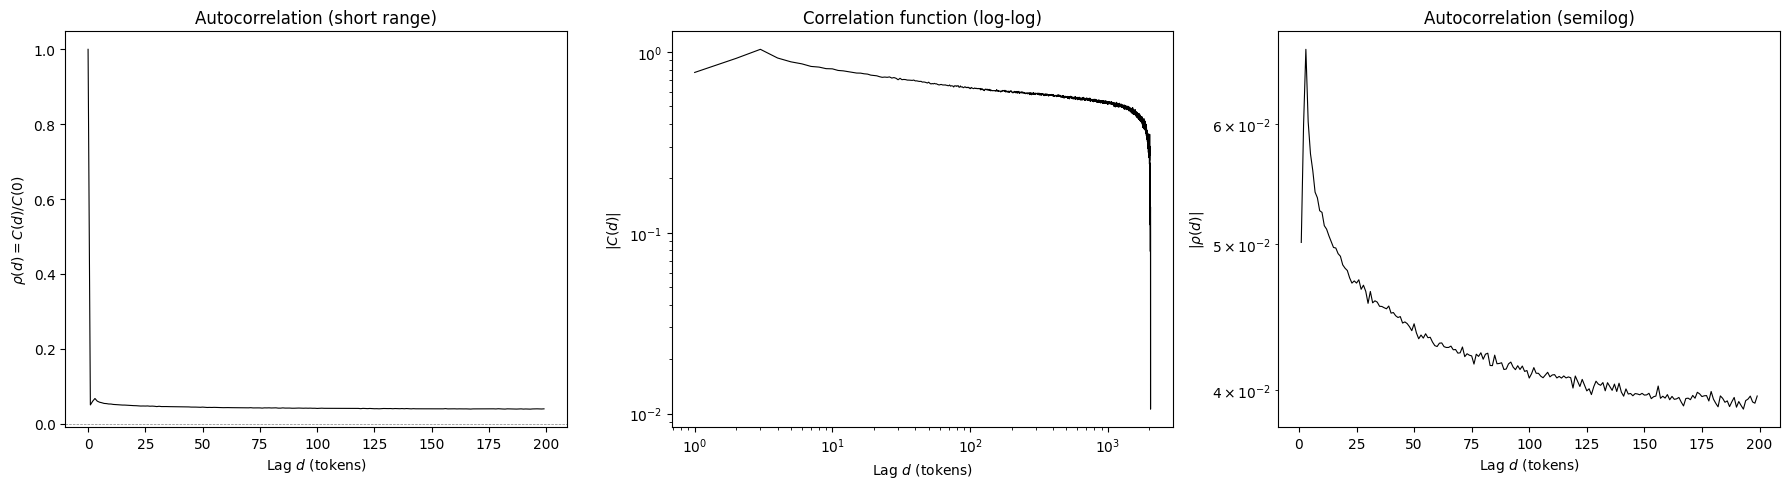

In [25]:
rho = C_all / C_all[0]  # normalized autocorrelation
lags = np.arange(len(C_all))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Linear scale, short range
max_show = 200
axes[0].plot(lags[:max_show], rho[:max_show], 'k-', lw=0.8)
axes[0].axhline(0, color='gray', ls='--', lw=0.5)
axes[0].set_xlabel('Lag $d$ (tokens)')
axes[0].set_ylabel(r'$\rho(d) = C(d)/C(0)$')
axes[0].set_title('Autocorrelation (short range)')

# Log-log
d_pos = lags[1:]  # skip d=0 for log
axes[1].plot(d_pos, np.abs(C_all[1:]), 'k-', lw=0.8)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Lag $d$ (tokens)')
axes[1].set_ylabel('$|C(d)|$')
axes[1].set_title('Correlation function (log-log)')

# Log-linear (semilog) to look for exponential decay
axes[2].plot(lags[1:max_show], np.abs(rho[1:max_show]), 'k-', lw=0.8)
axes[2].set_yscale('log')
axes[2].set_xlabel('Lag $d$ (tokens)')
axes[2].set_ylabel(r'$|\rho(d)|$')
axes[2].set_title('Autocorrelation (semilog)')

plt.tight_layout()
plt.show()


## 5. Power-law fits

If correlations decay as a power law $C(d) \sim d^{-\gamma}$, a log-log plot should be linear. Let's fit to identify the exponent.

Power-law fit: C(d) ~ 0.9395 * d^(-0.083)


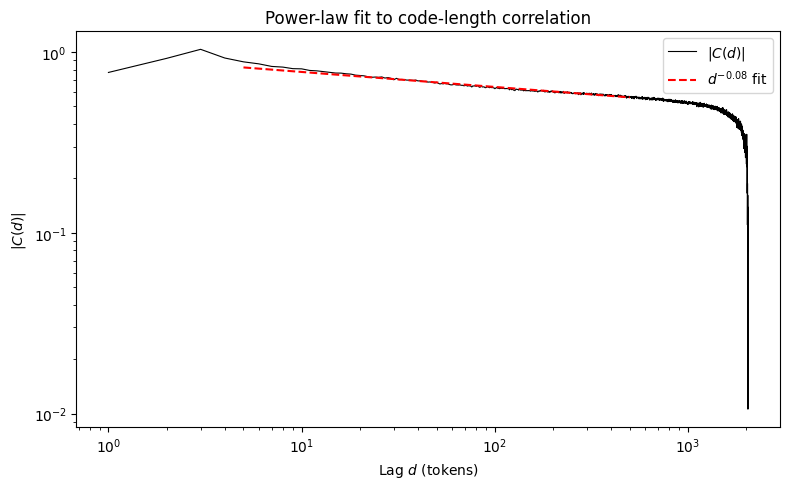

In [26]:
def fit_power_law(d, C, d_min=5, d_max=500):
    """Fit C(d) ~ A * d^(-gamma) in the range [d_min, d_max]."""
    sel = (d >= d_min) & (d <= d_max) & (C > 0)
    log_d = np.log(d[sel])
    log_C = np.log(C[sel])
    coeffs = np.polyfit(log_d, log_C, 1)
    gamma = -coeffs[0]
    A = np.exp(coeffs[1])
    return gamma, A

d_arr = np.arange(1, len(C_all))
C_pos = np.abs(C_all[1:])

gamma, A = fit_power_law(d_arr, C_pos)
print(f'Power-law fit: C(d) ~ {A:.4f} * d^(-{gamma:.3f})')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(d_arr, C_pos, 'k-', lw=0.8, label='$|C(d)|$')
fit_d = np.logspace(np.log10(5), np.log10(500), 100)
ax.plot(fit_d, A * fit_d**(-gamma), 'r--', lw=1.5, label=f'$d^{{-{gamma:.2f}}}$ fit')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Lag $d$ (tokens)')
ax.set_ylabel('$|C(d)|$')
ax.legend()
ax.set_title('Power-law fit to code-length correlation')
plt.tight_layout()
plt.show()


## 6. Power spectral density

The power spectral density $S(f)$ is the Fourier transform of $C(d)$. For a power-law correlator $C(d) \sim d^{-\gamma}$, we expect $S(f) \sim f^{\gamma - 1}$ (up to subtleties at low $f$). This gives another view of the characteristic scales.

In [ ]:
def power_spectral_density(delta, mask):
    """Average power spectral density over sequences."""
    N, T = delta.shape
    psd_sum = np.zeros(T // 2 + 1)
    count = 0
    
    for i in range(N):
        m = mask[i]
        L = int(m.sum())  # number of valid tokens
        if L < 10:
            continue
        d = delta[i, m][:L]  # contiguous valid tokens
        fd = np.fft.rfft(d, n=T)
        psd_sum += np.abs(fd)**2 / L
        count += 1
    
    psd = psd_sum / count
    freqs = np.fft.rfftfreq(T)
    return freqs, psd

freqs, psd = power_spectral_density(delta_cl.astype(np.float64), mask)

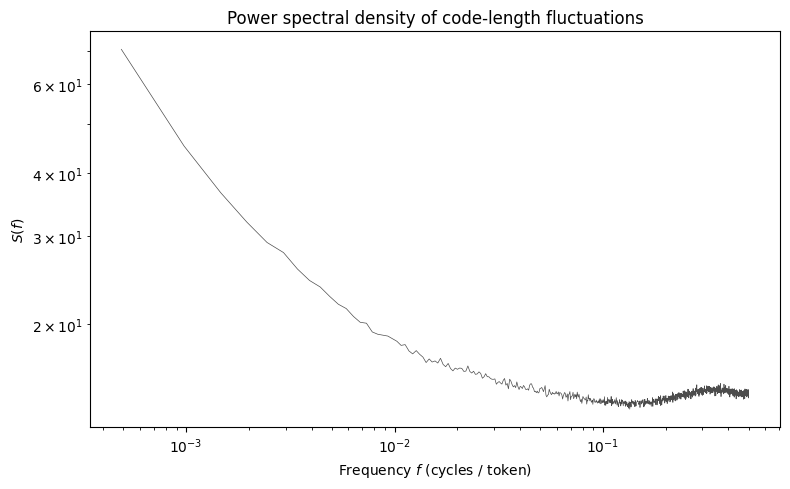

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
pos_f = freqs > 0
ax.plot(freqs[pos_f], psd[pos_f], 'k-', lw=0.5, alpha=0.7)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Frequency $f$ (cycles / token)')
ax.set_ylabel('$S(f)$')
ax.set_title('Power spectral density of code-length fluctuations')
plt.tight_layout()
plt.show()

## 7. Characteristic time scales

Several ways to extract characteristic scales:
1. **Correlation time** $\tau_c = \sum_{d=1}^{\infty} |\rho(d)|$ (integral of autocorrelation)
2. **Half-life** — smallest $d$ where $\rho(d) < 0.5$
3. **$1/e$ time** — where $\rho(d) < 1/e$
4. **Running integral** — see how $\tau_c(D) = \sum_{d=1}^{D} \rho(d)$ grows with cutoff

Half-life (rho < 0.5): d = 1 tokens
1/e time  (rho < 1/e): d = 1 tokens


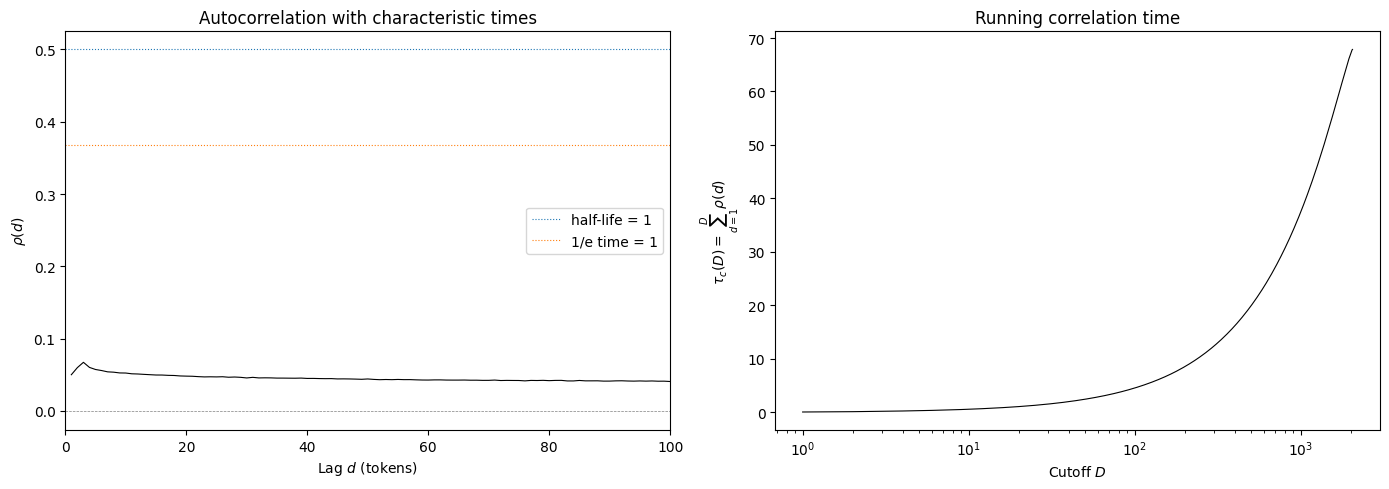

Integrated correlation time (full): tau_c = 67.86 tokens


In [29]:
# Half-life and 1/e time
half_life = np.argmax(rho[1:] < 0.5) + 1 if np.any(rho[1:] < 0.5) else len(rho)
e_time = np.argmax(rho[1:] < 1/np.e) + 1 if np.any(rho[1:] < 1/np.e) else len(rho)

print(f'Half-life (rho < 0.5): d = {half_life} tokens')
print(f'1/e time  (rho < 1/e): d = {e_time} tokens')

# Running integral of autocorrelation
tau_running = np.cumsum(rho[1:])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lags[1:], rho[1:], 'k-', lw=0.8)
axes[0].axhline(0.5, color='C0', ls=':', lw=0.8, label=f'half-life = {half_life}')
axes[0].axhline(1/np.e, color='C1', ls=':', lw=0.8, label=f'1/e time = {e_time}')
axes[0].axhline(0, color='gray', ls='--', lw=0.5)
axes[0].set_xlim(0, 100)
axes[0].set_xlabel('Lag $d$ (tokens)')
axes[0].set_ylabel(r'$\rho(d)$')
axes[0].legend()
axes[0].set_title('Autocorrelation with characteristic times')

axes[1].plot(np.arange(1, len(tau_running)+1), tau_running, 'k-', lw=0.8)
axes[1].set_xscale('log')
axes[1].set_xlabel('Cutoff $D$')
axes[1].set_ylabel(r'$\tau_c(D) = \sum_{d=1}^{D} \rho(d)$')
axes[1].set_title('Running correlation time')

plt.tight_layout()
plt.show()

print(f'Integrated correlation time (full): tau_c = {tau_running[-1]:.2f} tokens')

## 8. Dependence on position regime

The mean code length decreases strongly with position. The correlation structure may differ between early positions (short context, high $\bar\ell$) and late positions (long context, low $\bar\ell$). Let's split and compare.

In [30]:
def corr_in_window(cl, mask, mean_per_pos, t_start, t_end):
    """Compute correlation function restricted to positions [t_start, t_end)."""
    cl_win = cl[:, t_start:t_end]
    mask_win = mask[:, t_start:t_end]
    mean_win = mean_per_pos[t_start:t_end]
    delta_win = (cl_win - mean_win) * mask_win
    return corr_direct(delta_win.astype(np.float64), mask_win)


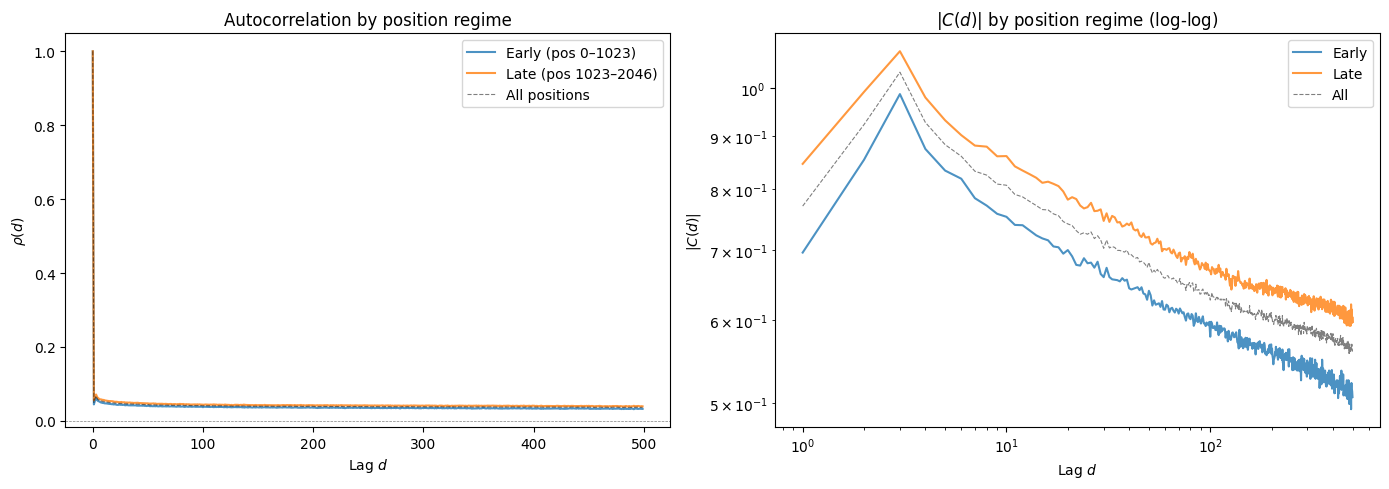

In [31]:
T = cl.shape[1]
T_mid = T // 2

C_early, _ = corr_in_window(cl, mask, mean_per_pos, 0, T_mid)
C_late, _  = corr_in_window(cl, mask, mean_per_pos, T_mid, T)

rho_early = C_early / C_early[0]
rho_late = C_late / C_late[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

max_d = min(T_mid, 500)
d_range = np.arange(max_d)

axes[0].plot(d_range, rho_early[:max_d], label=f'Early (pos 0\u2013{T_mid})', alpha=0.8)
axes[0].plot(d_range, rho_late[:max_d], label=f'Late (pos {T_mid}\u2013{T})', alpha=0.8)
axes[0].plot(d_range, rho[:max_d], 'k--', lw=0.8, label='All positions', alpha=0.5)
axes[0].axhline(0, color='gray', ls='--', lw=0.5)
axes[0].set_xlabel('Lag $d$')
axes[0].set_ylabel(r'$\rho(d)$')
axes[0].legend()
axes[0].set_title('Autocorrelation by position regime')

d_pos = np.arange(1, max_d)
axes[1].plot(d_pos, np.abs(C_early[1:max_d]), label='Early', alpha=0.8)
axes[1].plot(d_pos, np.abs(C_late[1:max_d]), label='Late', alpha=0.8)
axes[1].plot(d_pos, np.abs(C_all[1:max_d]), 'k--', lw=0.8, label='All', alpha=0.5)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Lag $d$')
axes[1].set_ylabel('$|C(d)|$')
axes[1].legend()
axes[1].set_title('$|C(d)|$ by position regime (log-log)')

plt.tight_layout()
plt.show()


## 9. Compare with c4 corpus

The flat `c4` data has a different preprocessing. Load it for comparison against `newc4`.

In [ ]:
cl2, attn2 = load_codelengths(data_root / 'c4', max_files=2000)

mask2 = attn2[:, 1:cl2.shape[1]+1].astype(bool)
count2 = mask2.sum(axis=0)
mean2 = np.where(count2 > 0, (cl2 * mask2).sum(axis=0) / count2, 0)
delta2 = (cl2 - mean2) * mask2

C2, _ = corr_direct(delta2.astype(np.float64), mask2)
rho2 = C2 / C2[0]

print(f'c4: {cl2.shape[0]} seqs, {cl2.shape[1]} positions')
print(f'C(0) = {C2[0]:.4f}, mean code length = {mean2[100:].mean():.3f} bits')


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

max_d = 500
d_range = np.arange(max_d)
d_pos = np.arange(1, max_d)

axes[0].plot(d_range, rho[:max_d], label='newc4', alpha=0.8)
axes[0].plot(d_range[:len(rho2)], rho2[:max_d], label='c4', alpha=0.8)
axes[0].axhline(0, color='gray', ls='--', lw=0.5)
axes[0].set_xlabel('Lag $d$ (tokens)')
axes[0].set_ylabel(r'$\rho(d)$')
axes[0].legend()
axes[0].set_title('Comparing corpora')

axes[1].plot(d_pos, np.abs(C_all[1:max_d]), label='newc4', alpha=0.8)
axes[1].plot(d_pos, np.abs(C2[1:max_d]), label='c4', alpha=0.8)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Lag $d$ (tokens)')
axes[1].set_ylabel('$|C(d)|$')
axes[1].legend()
axes[1].set_title('$|C(d)|$ comparison (log-log)')

plt.tight_layout()
plt.show()


## 10. Correlation with global vs. local mean subtraction

Above we subtracted the position-dependent mean $\bar\ell(n)$. Alternatively, we could subtract:
- A **global** mean (single number across all positions)
- A **per-sequence** mean
- A **running** mean with some window

These give different correlation functions; the difference reveals what part of the fluctuation comes from the systematic position dependence vs. genuine temporal structure.

In [36]:
# Global mean subtraction
global_mean = (cl * mask).sum() / mask.sum()
delta_global = (cl - global_mean) * mask
C_global, _ = corr_direct(delta_global.astype(np.float64), mask)

# Per-sequence mean subtraction
seq_means = (cl * mask).sum(axis=1, keepdims=True) / mask.sum(axis=1, keepdims=True).clip(1)
delta_seq = (cl - seq_means) * mask
C_seq, _ = corr_direct(delta_seq.astype(np.float64), mask)

rho_global = C_global / C_global[0]
rho_seq = C_seq / C_seq[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

max_d = 500
d_range = np.arange(max_d)
d_pos = np.arange(1, max_d)

axes[0].plot(d_range, rho_global[:max_d], label='Global mean', alpha=0.8)
axes[0].plot(d_range, rho[:max_d], label='Position-dep. mean', alpha=0.8)
axes[0].plot(d_range, rho_seq[:max_d], label='Per-sequence mean', alpha=0.8)
axes[0].axhline(0, color='gray', ls='--', lw=0.5)
axes[0].set_xlabel('Lag $d$')
axes[0].set_ylabel(r'$\rho(d)$')
axes[0].legend()
axes[0].set_title('Effect of mean subtraction')

axes[1].plot(d_pos, np.abs(C_global[1:max_d]), label='Global mean', alpha=0.8)
axes[1].plot(d_pos, np.abs(C_all[1:max_d]), label='Position-dep. mean', alpha=0.8)
axes[1].plot(d_pos, np.abs(C_seq[1:max_d]), label='Per-sequence mean', alpha=0.8)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Lag $d$')
axes[1].set_ylabel('$|C(d)|$')
axes[1].legend()
axes[1].set_title('$|C(d)|$ for different mean subtractions (log-log)')

plt.tight_layout()
plt.show()


Direct correlations:   0%|                                                                    | 2/2046 [00:00<04:31,  7.52it/s]

KeyboardInterrupt: 

## 11. Correlation of conditional entropy

The code length depends on which token actually appears; the conditional entropy $\mathcal{S}_{\rm cond}$ depends only on the model's predicted distribution. Compare their correlation functions.

In [33]:
def load_entropy(corpus_dir, max_files=None):
    """Load per-token conditional entropy. Handles flat and grouped layouts."""
    if (corpus_dir / 'entropy_t').is_dir():
        group_dirs = [corpus_dir]
    else:
        group_dirs = sorted(
            p for p in corpus_dir.iterdir()
            if p.is_dir() and p.name.startswith('group_')
        )
    
    ent_list = []
    n_loaded = 0
    for gdir in group_dirs:
        ent_dir = gdir / 'entropy_t'
        files = sorted(f for f in os.listdir(ent_dir) if f.endswith('.npy'))
        for f in tqdm(files, desc=f'Loading entropy {gdir.name}', leave=False):
            ent_list.append(np.load(ent_dir / f))
            n_loaded += 1
            if max_files is not None and n_loaded >= max_files:
                break
        if max_files is not None and n_loaded >= max_files:
            break
    
    return np.concatenate(ent_list, axis=0)


In [34]:
ent = load_entropy(data_root / corpus, max_files=2000)

# Align entropy with codelength arrays
ent_aligned = ent[:, :cl.shape[1]]
print(f'Entropy shape: {ent.shape}, aligned: {ent_aligned.shape}')

mask_ent = mask[:, :ent_aligned.shape[1]]
count_ent = mask_ent.sum(axis=0)
mean_ent_pos = np.where(count_ent > 0, (ent_aligned * mask_ent).sum(axis=0) / count_ent, 0)
delta_ent = (ent_aligned - mean_ent_pos) * mask_ent

C_ent, _ = corr_direct(delta_ent.astype(np.float64), mask_ent)
rho_ent = C_ent / C_ent[0]


Entropy shape: (10000, 2047), aligned: (10000, 2046)


KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

max_d = 500
d_range = np.arange(max_d)
d_pos = np.arange(1, max_d)

axes[0].plot(d_range, rho[:max_d], label=r'Code length $\ell$', alpha=0.8)
axes[0].plot(d_range, rho_ent[:max_d], label=r'Cond. entropy $\mathcal{S}_{\rm cond}$', alpha=0.8)
axes[0].axhline(0, color='gray', ls='--', lw=0.5)
axes[0].set_xlabel('Lag $d$')
axes[0].set_ylabel(r'$\rho(d)$')
axes[0].legend()
axes[0].set_title('Code length vs entropy autocorrelation')

axes[1].plot(d_pos, np.abs(C_all[1:max_d]), label=r'$|C_\ell(d)|$', alpha=0.8)
axes[1].plot(d_pos, np.abs(C_ent[1:max_d]), label=r'$|C_{\mathcal{S}}(d)|$', alpha=0.8)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Lag $d$')
axes[1].set_ylabel('$|C(d)|$')
axes[1].legend()
axes[1].set_title('Correlation magnitude (log-log)')

plt.tight_layout()
plt.show()

## 12. Cross-correlation between code length and entropy

Are the fluctuations in $\ell_n$ and $\mathcal{S}_{\rm cond,n}$ correlated at the same position? At different positions?

In [ ]:
def cross_corr_direct(delta_a, delta_b, mask, max_lag=None):
    """Direct cross-correlation between two signals, averaged over sequences."""
    N, T = delta_a.shape
    if max_lag is None:
        max_lag = T - 1
    max_lag = min(max_lag, T - 1)
    
    C = np.zeros(max_lag + 1)
    npairs = np.zeros(max_lag + 1)
    
    for d in tqdm(range(max_lag + 1), desc='Cross-correlations', leave=False):
        prod = delta_a[:, :T-d] * delta_b[:, d:T]
        valid = mask[:, :T-d] & mask[:, d:T]
        npairs[d] = valid.sum()
        C[d] = prod[valid].sum() / npairs[d] if npairs[d] > 0 else 0
    
    return C

T_common = min(delta_cl.shape[1], delta_ent.shape[1])
C_cross = cross_corr_direct(
    delta_cl[:, :T_common].astype(np.float64),
    delta_ent[:, :T_common].astype(np.float64),
    mask[:, :T_common]
)

# Normalize to get cross-correlation coefficient
rho_cross = C_cross / np.sqrt(C_all[0] * C_ent[0])


In [ ]:
max_d = 200
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(max_d), rho_cross[:max_d], 'k-', lw=0.8)
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_xlabel('Lag $d$ (tokens)')
ax.set_ylabel(r'Cross-correlation $\rho_{\ell, \mathcal{S}}(d)$')
ax.set_title(r'Cross-correlation: code length $\ell$ vs entropy $\mathcal{S}_{\rm cond}$')
print(f'Equal-time cross-correlation rho(0) = {rho_cross[0]:.4f}')
plt.tight_layout()
plt.show()

## 13. Explore other corpora

The DCLM pipeline has several corpora: BBC, poetry, Wikipedia, etc. These may show very different correlation structures.

In [ ]:
def quick_corr(corpus_path, max_files=500):
    """One-shot: load data, compute correlation, return rho and C."""
    cl_i, attn_i = load_codelengths(corpus_path, max_files=max_files)
    mask_i = attn_i[:, 1:cl_i.shape[1]+1].astype(bool)
    count_i = mask_i.sum(axis=0)
    mean_i = np.where(count_i > 0, (cl_i * mask_i).sum(axis=0) / count_i, 0)
    delta_i = (cl_i - mean_i) * mask_i
    C_i, _ = corr_direct(delta_i.astype(np.float64), mask_i)
    rho_i = C_i / C_i[0]
    return rho_i, C_i


In [ ]:
# Scan all available corpora (flat or grouped)
available_corpora = []
for name in sorted(os.listdir(data_root)):
    p = data_root / name
    if not p.is_dir():
        continue
    if (p / 'codelength_t').is_dir():
        available_corpora.append(name)
    elif any((g / 'codelength_t').is_dir() for g in p.iterdir() if g.is_dir() and g.name.startswith('group_')):
        available_corpora.append(name)
print('Available corpora:', available_corpora)


In [ ]:
# Compute correlation for each available corpus
results = {}
for name in available_corpora:
    print(f'\n--- {name} ---')
    try:
        rho_i, C_i = quick_corr(data_root / name, max_files=500)
        results[name] = (rho_i, C_i)
    except Exception as e:
        print(f'  Skipped: {e}')


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

max_d = 500
for name, (rho_i, C_i) in results.items():
    d_show = min(max_d, len(rho_i))
    axes[0].plot(np.arange(d_show), rho_i[:d_show], label=name, alpha=0.7)
    axes[1].plot(np.arange(1, d_show), np.abs(C_i[1:d_show]), label=name, alpha=0.7)

axes[0].axhline(0, color='gray', ls='--', lw=0.5)
axes[0].set_xlabel('Lag $d$ (tokens)')
axes[0].set_ylabel(r'$\rho(d)$')
axes[0].legend(fontsize=8)
axes[0].set_title('Autocorrelation across corpora')

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Lag $d$ (tokens)')
axes[1].set_ylabel('$|C(d)|$')
axes[1].legend(fontsize=8)
axes[1].set_title('$|C(d)|$ across corpora (log-log)')

plt.tight_layout()
plt.show()

## Scratch space

Use cells below for ad hoc exploration.